# Анализ данных продаж интернет-магазина

# Оглавление
1. [Описание проекта](#cell1)
2. [Приоритизация гипотез](#cell2)
3. [Анализ результатов A/B-теста](#cell3)
   
   3.1 [Предобработка данных](#cell3.1)
   
   3.2 [Расчет кумулятивных метрик](#cell3.2)
   
   3.2.1 [Расчет кумулятивной выручки по группам](#cell3.2.1)
   
   3.2.2 [Расчет кумулятивного среднего чека по группам](#cell3.2.2)
   
   3.2.3 [График относительного различия  среднего чека по группам](#cell3.2.3)
   
   3.2.4 [Расчет кумулятивного среднего количества заказов на посетителя](#cell3.2.4)
   
   3.2.5 [График относительного различия среднего количества заказов на посетителя по группам](#cell3.2.5)
   
   3.3 [Поиск выбросов и аномалий в данных](#cell3.3)
   
   3.4 [Расчет статистической значимости различий между группами по «сырым» данным (до удаления выбросов)](#cell3.4)
   
   3.5 [Расчет статистической значимости различий между группами по очищенным данным (после удаления выбросов)](#cel3.5)      
  
5. [Сводный вывод](#cell4)

## Описание проекта <div id="cell1"></div> 

Требуется провести анализ данных продаж крупного интернет-магазина.  Для отдела маркетинга необходимо приоритизировать подготовленные им гипотезы и проанализировать результаты проведенного А/В теста, проверить гипотезы о наличии статистически значимых различий в метриках между разными группами покупателей и сделать вывод о завершении теста и победе одной из групп или продолжении тестирования

**План работ:**
- приоритизировать гипотезы, используя ICE и RICE_SCORE
- выполнить предобработку данных
- рассчитать и проанализировать кумулятивные данные по выручке, чеку, количеству заказов на посетителя по группам
- проверить наличие выбросов и аномалий в группах, очистить данные при необходимости 
- проверить статистическую значимость различий в среднем чеке заказа и количеству заказов на пользователя по группам
- принять решение о завершении или продолжении тестирования

## Приоритизация гипотез <div id="cell2"></div> 

In [1]:
# импорт библиотек
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import scipy.stats as stats
from pandas import option_context

# задаем макс.ширину столбца
pd.set_option('max_colwidth', 120)

In [2]:
# выгрузка  данных
data1 = pd.read_csv('hypothesis.csv')
data1.head(10)

,Hypothesis,Reach,Impact,Confidence,Efforts
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5


In [3]:
# расчет ICE_SCORE для приоритизации гипотез. сортировка их по убыванию приоритета по ICE
data1['ICE_SCORE'] = (data1['Impact']*data1['Confidence']/data1['Efforts']).round(1)
data1.sort_values(by = 'ICE_SCORE', ascending = False).head(10)

,Hypothesis,Reach,Impact,Confidence,Efforts,ICE_SCORE
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5,16.2
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6,13.3
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5,11.2
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3,8.0
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3,7.0
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10,2.0
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3,1.3
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8,1.1
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1,1.0


In [4]:
# расчет RICE_SCORE для приоритизации гипотез. сортировка их по убыванию приоритета по RICE
data1['RICE_SCORE'] = data1['Reach']*data1['Impact']*data1['Confidence']/data1['Efforts']
data1.sort_values(by = 'RICE_SCORE', ascending = False).head(10)


,Hypothesis,Reach,Impact,Confidence,Efforts,ICE_SCORE,RICE_SCORE
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5,11.2,112.0
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3,7.0,56.0
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6,13.3,40.0
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3,8.0,40.0
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5,16.2,16.2
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8,1.1,9.0
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10,2.0,4.0
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3,1.3,4.0
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1,1.0,3.0


**Вывод**: 
- по ICE_SCORE самыми приоритетными являются гипотезы под номером 8, 0, 7, т.к. у этих гипотез наиболее сильное влияние на пользователей, у остальных гипотез ICE_SCORE ниже на 30% и более   
- по RICE_SCORE приоритезация отличается, самыми приоритетными являются гипотезы под номером 7, 2, 0, 6 (гипотез 0 и 2 равный RICE_SCORE). У гипотез 7 и 2 наибольший охват пользователей, что повлияло на приоритезацию. У остальных гипотез RICE_SCORE существенно ниже (в несколько раз)
- следует отметить, что у гипотез 2 и 6 наименьшая стоимость тестирования (3 балла), по сравнению с другими лидерами, у остальных гипотез-лидеров средняя стоимость тестирования (по 5 и 6 баллов)
- следует отметить достаточно высокую уверенность в правильности оценок параметров у всех гипотез-лидеров (7 и более баллов)
- по совокупности  ICE и RICE SCORE следует протестировать ТОП-5 гипотез:  
    - №7 Добавить форму подписки на все основные страницы (лидер по охвату при достаточно высоком влиянии  и средней стоимости)
    - №2 Добавить блоки рекомендаций товаров на сайт (высокий охват, низкое влияние, но и низкая стоимость)
    - №0 Добавить два новых канала привлечения трафика (несмотря на невысокий охват, максимальное влияние и средняя стоимость)
    - №8 Запустить акцию, дающую скидку на товар(высокое влияние, средняя стоимость, хотя и минимальный охват)
    - №6 Показать на главной странице баннеры (средний охват, низкое влияние, но и низкая стоимость)
    

## Анализ результатов A/B-теста <a id="cell3"></a> 

### Предобработка данных <a id="cell3.1"></a> 


In [5]:
# выгрузка и ознакомление с данными
orders = pd.read_csv('orders.csv')
visitors = pd.read_csv('visitors.csv')
display(orders.head())
visitors.head()

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B


,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


In [6]:
orders.info()
visitors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   transactionId  1197 non-null   int64 
 1   visitorId      1197 non-null   int64 
 2   date           1197 non-null   object
 3   revenue        1197 non-null   int64 
 4   group          1197 non-null   object
dtypes: int64(3), object(2)
memory usage: 46.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      62 non-null     object
 1   group     62 non-null     object
 2   visitors  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


In [7]:
# преобразование даты в соответствующий формат
orders['date'] = pd.to_datetime(orders['date'],format='%Y-%m-%d')
visitors['date'] = pd.to_datetime(visitors['date'],format='%Y-%m-%d')
orders.info()
visitors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  1197 non-null   int64         
 1   visitorId      1197 non-null   int64         
 2   date           1197 non-null   datetime64[ns]
 3   revenue        1197 non-null   int64         
 4   group          1197 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 46.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      62 non-null     datetime64[ns]
 1   group     62 non-null     object        
 2   visitors  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB


In [8]:
# проверка наличия строк-дубликатов
print(orders.duplicated().sum())
visitors.duplicated().sum()

0


0

In [9]:
# проверяем за какой период данные
print(orders['date'].max(), orders['date'].min())
print(visitors['date'].max(), visitors['date'].min())

# проверяем разбивку по группам
print(orders['group'].value_counts())
visitors['group'].value_counts()

2019-08-31 00:00:00 2019-08-01 00:00:00
2019-08-31 00:00:00 2019-08-01 00:00:00
B    640
A    557
Name: group, dtype: int64


B    31
A    31
Name: group, dtype: int64

In [10]:
# провекрка ID поситителей и заказов на дубликаты
print(orders['transactionId'].duplicated().sum())
orders['visitorId'].duplicated().sum()

0


166

In [11]:
# проверяем входит ли один пользователь в разные группы
orders.groupby('visitorId').agg({'group' : 'nunique'}).reset_index()

,visitorId,group
0,5114589,1
1,6958315,1
2,8300375,2
3,11685486,1
4,39475350,1
...,...,...
1026,4266935830,2
1027,4278982564,1
1028,4279090005,1
1029,4281247801,1


Выявлены пользователи, которые входят в обе группы одновременно. Необходимо удалить данных пользователей

In [12]:
# формируем список ID пользователей, которые входят сразу в две группы
double = orders.groupby('visitorId').agg({'group' : 'nunique'}).reset_index().query('group>1')['visitorId'].to_list()
print(double)
len(double)

[8300375, 199603092, 232979603, 237748145, 276558944, 351125977, 393266494, 457167155, 471551937, 477780734, 818047933, 963407295, 1230306981, 1294878855, 1316129916, 1333886533, 1404934699, 1602967004, 1614305549, 1648269707, 1668030113, 1738359350, 1801183820, 1959144690, 2038680547, 2044997962, 2378935119, 2458001652, 2579882178, 2587333274, 2600415354, 2654030115, 2686716486, 2712142231, 2716752286, 2780786433, 2927087541, 2949041841, 2954449915, 3062433592, 3202540741, 3234906277, 3656415546, 3717692402, 3766097110, 3803269165, 3891541246, 3941795274, 3951559397, 3957174400, 3963646447, 3972127743, 3984495233, 4069496402, 4120364173, 4186807279, 4256040402, 4266935830]


58

In [13]:
# удаляем 58 пользователей, которые входят сразу в обе группы
orders = orders.query('visitorId not in @double')

#  проверка 
orders.groupby('visitorId').agg({'group' : 'nunique'}).query('group>1')

,group
visitorId,


**Вывод**
проведена предобработка данных:
- проверены строки-дубликаты
- столбцы с датой приведены к соответствующему формату
- ID пользователей и заказов проверены на дубликаты: дубликатов заказов нет, дубликаты пользователей есть (один пользователь может делать несколько заказов)
- проведена проверка пользователей на пересечение групп: выявлено 58 пользователей, которые входят сразу в обе группы. Данные пользователи удалены.

### Расчет кумулятивных метрик <a id="cell3.2"></a> 

In [14]:
# создаем массив уникальных пар значений дат и групп теста
datesGroups = orders[['date','group']].drop_duplicates() 
display(datesGroups)

# агрегированные кумулятивные по дням данные о транзакциях
ordersAggregated = datesGroups.apply(lambda x: orders[np.logical_and(orders['date'] <= x['date'], orders['group'] == x['group'])]\
                                     .agg({'date' : 'max', 'group' : 'max', 'transactionId' : 'nunique', 'visitorId' : 'nunique', 'revenue' : 'sum'}), axis=1)\
                                     .sort_values(by=['date','group'])
display(ordersAggregated)

# агрегированные кумулятивные по дням данные о посетителях
visitorsAggregated = datesGroups.apply(lambda x: visitors[np.logical_and(visitors['date'] <= x['date'], visitors['group'] == x['group'])]\
                                       .agg({'date' : 'max', 'group' : 'max', 'visitors' : 'sum'}), axis=1)\
                                       .sort_values(by=['date','group'])
display(visitorsAggregated)

,date,group
0,2019-08-15,B
7,2019-08-15,A
45,2019-08-16,A
47,2019-08-16,B
55,2019-08-01,A
...,...,...
1068,2019-08-12,A
1114,2019-08-13,B
1116,2019-08-13,A
1149,2019-08-14,B


,date,group,transactionId,visitorId,revenue
55,2019-08-01,A,23,19,142779
66,2019-08-01,B,17,17,59758
175,2019-08-02,A,42,36,234381
173,2019-08-02,B,40,39,221801
291,2019-08-03,A,66,60,346854
...,...,...,...,...,...
533,2019-08-29,B,510,490,4746610
757,2019-08-30,A,460,437,3311413
690,2019-08-30,B,531,511,4955833
958,2019-08-31,A,468,445,3364656


,date,group,visitors
55,2019-08-01,A,719
66,2019-08-01,B,713
175,2019-08-02,A,1338
173,2019-08-02,B,1294
291,2019-08-03,A,1845
...,...,...,...
533,2019-08-29,B,17708
757,2019-08-30,A,18037
690,2019-08-30,B,18198
958,2019-08-31,A,18736


In [15]:
# объединяем кумулятивные данные в одной таблице
cumulativeData = ordersAggregated.merge(visitorsAggregated, left_on=['date', 'group'], right_on=['date', 'group'])
cumulativeData.columns = ['date','group','orders','buyers','revenue','visitors']
cumulativeData

,date,group,orders,buyers,revenue,visitors
0,2019-08-01,A,23,19,142779,719
1,2019-08-01,B,17,17,59758,713
2,2019-08-02,A,42,36,234381,1338
3,2019-08-02,B,40,39,221801,1294
4,2019-08-03,A,66,60,346854,1845
...,...,...,...,...,...,...
57,2019-08-29,B,510,490,4746610,17708
58,2019-08-30,A,460,437,3311413,18037
59,2019-08-30,B,531,511,4955833,18198
60,2019-08-31,A,468,445,3364656,18736


#### Расчет кумулятивной выручки по группам <a id="cell3.2.1"></a> 

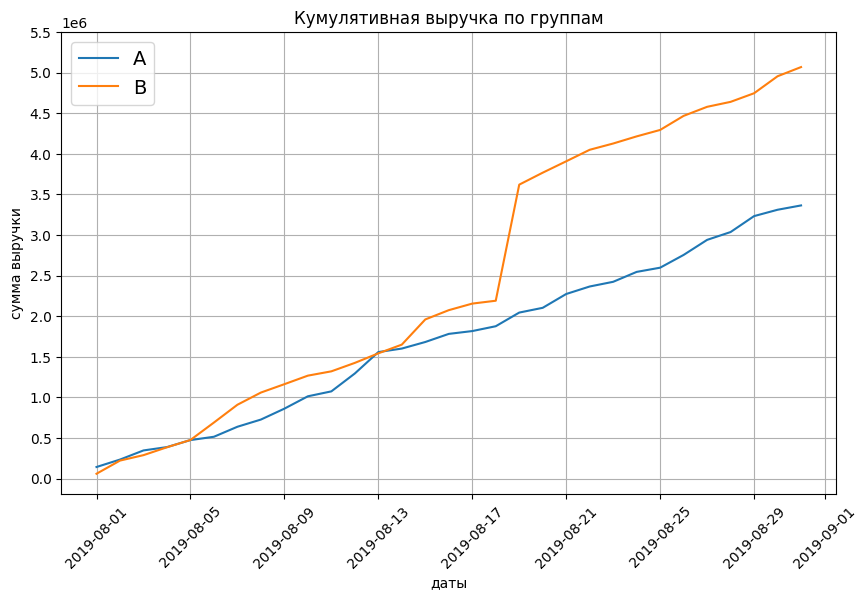

In [16]:
# датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе А
cumulativeRevenueA = cumulativeData[cumulativeData['group']=='A'][['date','revenue', 'orders']]

# датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе B
cumulativeRevenueB = cumulativeData[cumulativeData['group']=='B'][['date','revenue', 'orders']]

# строим графики кумулятивной выручки по группам
plt.figure(figsize=(10, 6))

plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue'], label='A')
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue'], label='B')

plt.title('Кумулятивная выручка по группам')
plt.xticks(rotation=45)
plt.yticks(np.arange(0, 6000000, step=500000))
plt.xlabel('даты')
plt.ylabel('сумма выручки')
plt.grid()
plt.legend(loc='upper left', fontsize=14) 
plt.show()

**Вывод**:
- выручка в обеих группах стабильно растет (рост наблюдается на каждом временном интервале)
- в начале периода тестирования кумулятивная выручка в обеих группах примерно одинаковая
- начиная примерно с середины периода тестирования (13 августа 2019) кумулятивная выручка группы В стабильно больше выручки группы А, разрыв увеличивался до конца месяца 
- наблюдается резкий скачок в выручке группы В примерно в период с 18 по 20 августа, следует дополнительно проанализировать показатели группы В в эти даты для выяснения причины такого скачка

#### Расчет кумулятивного среднего чека по группам <a id="cell3.2.2"></a> 

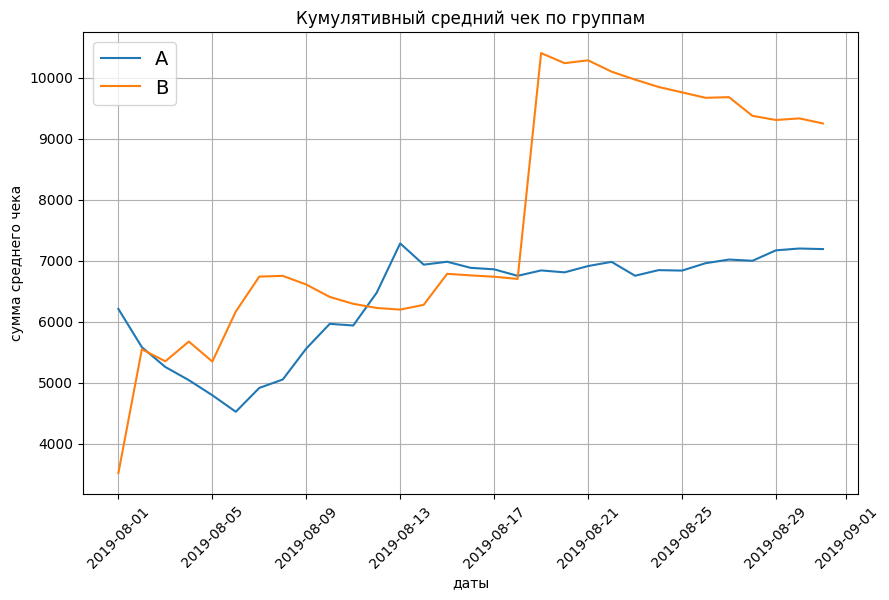

In [17]:
# графики кумулятивного среднего чека по группам
plt.figure(figsize=(10, 6))

plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue']/cumulativeRevenueA['orders'], label='A')
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue']/cumulativeRevenueB['orders'], label='B')

plt.title('Кумулятивный средний чек по группам')
plt.xticks(rotation=45)
plt.xlabel('даты')
plt.ylabel('сумма среднего чека')
plt.grid()
plt.legend(loc='upper left', fontsize=14) 
plt.show()

**Вывод** 
- средний чек весьма волатилен в начале периода тестирования, становится равномерным ближе к концу периода (после 21 августа 2019) и установился для группы В стабильно выше, чем для А
- наблюдается резкий скачок среднего чека в группе В  в период с 18 по 20 августа (средний чек вырос с 7 тыс, до 100 тыс руб), что говорит о крупных заказах в эти даты в группе В, следует дополнительно проанализировать заказы в этот период

#### График относительного различия  среднего чека по группам <a id="cell3.2.3"></a> 

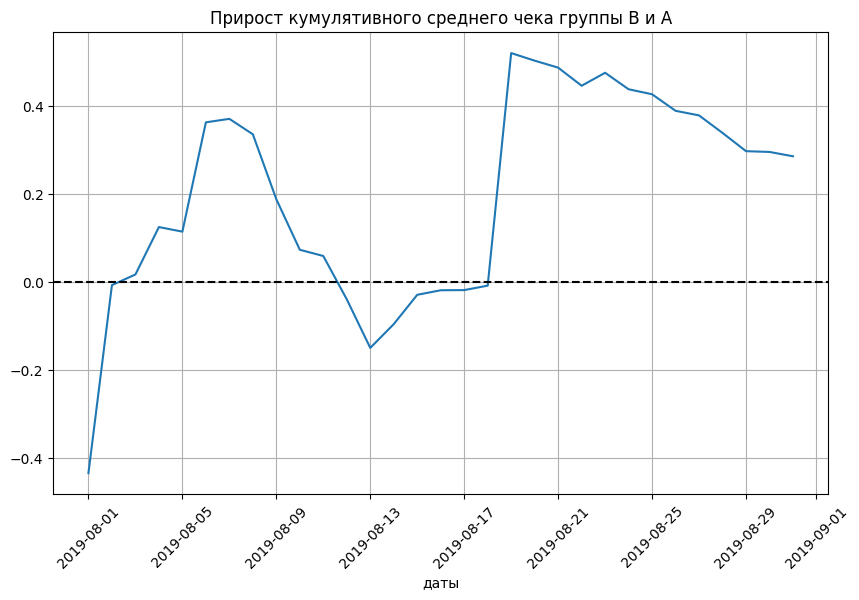

In [18]:
# график относительного различия среднего чека
# собираем данные в одном датафрейме
mergedCumulativeRevenue = cumulativeRevenueA.merge(cumulativeRevenueB, left_on='date', right_on='date', how='left', suffixes=['A', 'B'])

plt.figure(figsize=(10, 6))
# cтроим отношение средних чеков
plt.plot(mergedCumulativeRevenue['date'], (mergedCumulativeRevenue['revenueB']/mergedCumulativeRevenue['ordersB'])/(mergedCumulativeRevenue['revenueA']/mergedCumulativeRevenue['ordersA'])-1)

plt.title('Прирост кумулятивного среднего чека группы В и А')
plt.xticks(rotation=45)
plt.xlabel('даты')
plt.grid()
# добавляем ось X
plt.axhline(y=0, color='black', linestyle='--')
plt.show()

**Вывод**
- в нескольких точках график резко «скачет». Вероятно, в данных есть выбросы. Ближе к концу периода тестирвания кумулятивный средний чек в группе В выше чем, в А, но есть тенденция к снижению.


#### Расчет кумулятивного среднего количества заказов на посетителя <a id="cell3.2.4"></a> 

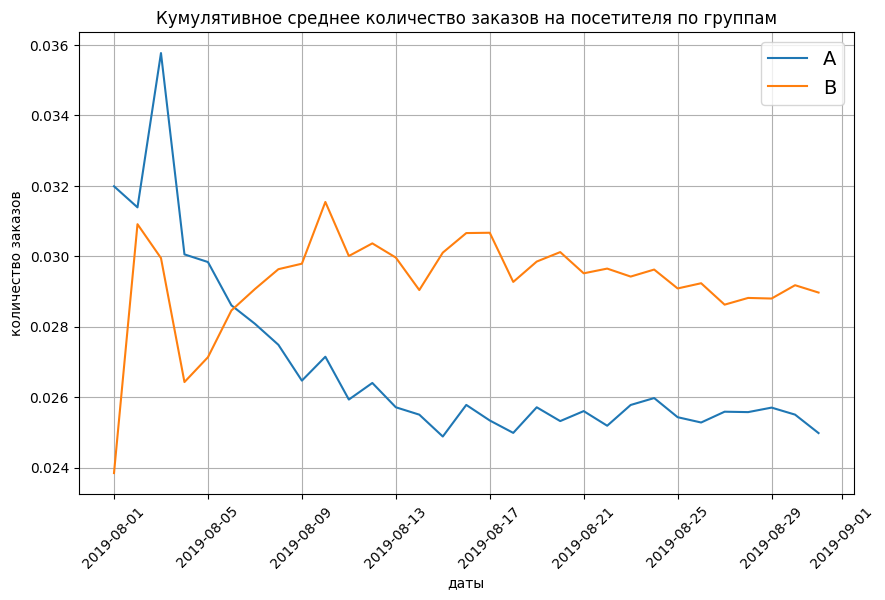

In [19]:
# считаем среднее количество заказов на посетителя
cumulativeData['conversion'] = cumulativeData['orders']/cumulativeData['visitors']

#  данные по группе A
cumulativeDataA = cumulativeData[cumulativeData['group']=='A']

# данные по группе B
cumulativeDataB = cumulativeData[cumulativeData['group']=='B']

# строим графики
plt.figure(figsize=(10, 6))
plt.plot(cumulativeDataA['date'], cumulativeDataA['conversion'], label='A')
plt.plot(cumulativeDataB['date'], cumulativeDataB['conversion'], label='B')

plt.title('Кумулятивное среднее количество заказов на посетителя по группам')
plt.xticks(rotation=45)
plt.xlabel('даты')
plt.ylabel('количество заказов')
plt.grid()
plt.legend(loc='upper right', fontsize=14) 
plt.show()


**Вывод**
- кумулятивное среднее количество заказов на посетителя волатильно в начале периода тестирования, с середины периода тестирования более стабильно, у группы В этот показатель выше, чему у группы А почти на всем периоде тестирования.

#### График относительного различия среднего количества заказов на посетителя по группам <a id="cell3.2.5"></a> 

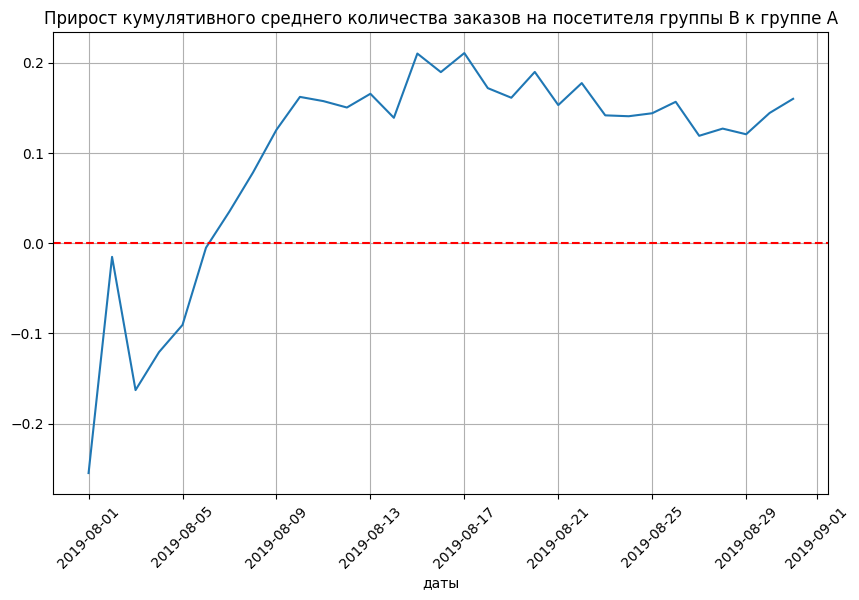

In [20]:
# график изменения кумулятивного среднего количества заказов на посетителя группы B к группе A:

mergedCumulativeConversions = cumulativeDataA[['date','conversion']].merge(cumulativeDataB[['date','conversion']], left_on='date', right_on='date', how='left', suffixes=['A', 'B'])

plt.figure(figsize=(10, 6))
plt.plot(mergedCumulativeConversions['date'], mergedCumulativeConversions['conversionB']/mergedCumulativeConversions['conversionA']-1)
plt.title('Прирост кумулятивного среднего количества заказов на посетителя группы B к группе A')
plt.xticks(rotation=45)
plt.xlabel('даты')
plt.grid()
plt.axhline(y=0, color='red', linestyle='--')
plt.show()


**Вывод**
- в начале периода тестирования были скачки показателя, в целом почти на всем периоде тестирования среднее количество заказов в группе В стабильно выше, чем в группе А

### Поиск выбросов и аномалий в данных <a id="cell3.3"></a> 

##### Точечный график стоимостей заказов

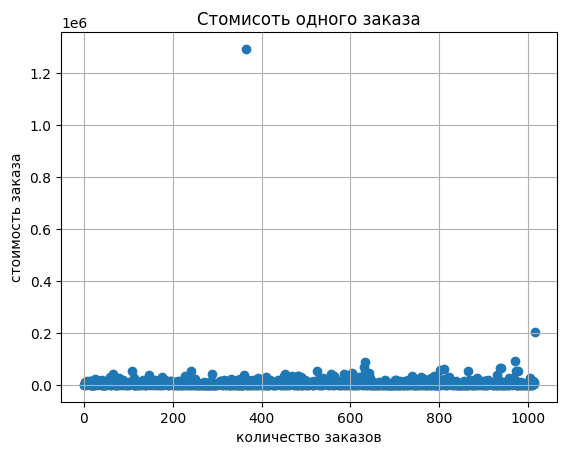

In [21]:
# точечная диаграмма стоимости заказа 
x_values = pd.Series(range(0,len(orders['revenue'])))
plt.scatter(x_values, orders['revenue']) 
plt.title('Стомисоть одного заказа')
plt.xlabel('количество заказов')
plt.ylabel('стоимость заказа')
plt.grid()
plt.show()

**Вывод** на диаграмме явно видны два заказа, стоимость которых выше остальных (1 заказ стоимость выше 1,2 млн, второй - 200 тыс). Данные заказы можно считать выбросами. Данные выбросы объясняют "скачки" в графиках кумулятивной выручки и среднего чека.

In [22]:
# расчет 95 и 99 перцентилей стоимости заказа
print(np.percentile(orders['revenue'], [95, 99])) 
revenue_extrem = np.percentile(orders['revenue'], 99)
revenue_extrem

[26785. 53904.]


53904.0

**Вывод** не более чем 5% заказов имеют стоимость выше 26,7 тыс.,  не более 1% заказов стоимостью выше 53,9 тыс. рублей. Отбрысываем верхние 1%, т.е. заказы стоимость которых превышает 54 тыс руб(округляем вверх до целого)

##### Точечный график количества заказов по пользователям

In [23]:
# расчет количества заказов по пользователям
ordersByUsers = (orders.groupby('visitorId', as_index=False).agg({'transactionId': 'nunique'})).sort_values(by='transactionId', ascending=False)

ordersByUsers.columns = ['visitorId', 'orders']

print(ordersByUsers.head(10)) 



      visitorId  orders
908  3967698036       3
55    249864742       3
478  2108163459       3
687  2988190573       3
890  3908431265       3
138   611059232       3
632  2742574263       3
157   678354126       2
323  1404560065       2
452  1985475298       2


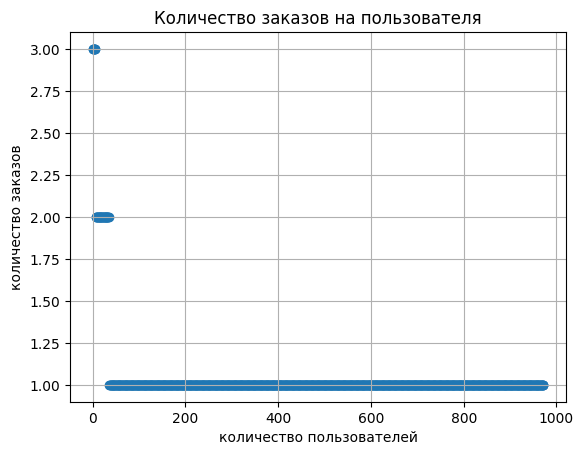

In [24]:
# точечная диаграмма количества заказов по пользователям
x_values = pd.Series(range(0,len(ordersByUsers)))
plt.scatter(x_values, ordersByUsers['orders']) 
plt.title('Количество заказов на пользователя')
plt.xlabel('количество пользователей')
plt.ylabel('количество заказов')
plt.grid()
plt.show()

**Вывод** нескоторые пользователи делали по 2 и более заказов, однако большинство делали 1 заказ

In [25]:
# расчет 95 и 99 перцентилей количество заказов на пользователя
print(np.percentile(ordersByUsers['orders'], [95, 99])) 
orders_extrem = np.percentile(ordersByUsers['orders'], 99)
orders_extrem

[1. 2.]


2.0

**Вывод** не более чем 5% пользователей сделали более 1 заказа,  не более 1% пользовтелей делали более 2 заказов. Отбрысываем верхние 1%, т.е. пользователей, которые совершали более 2 заказов.

### Расчет статистической значимости различий между группами по «сырым» данным (до удаления выбросов) <a id="cell3.4"></a> 

##### Расчет статистической значимости различий в среднем количестве заказов на посетителя  

Гипотеза : 
- Н0: среднее количество заказов на посетителя в группе А = среднему количеству заказов на посетителя в группе В
- Н1: среднее количество заказов на посетителя в группах А и В не равны
- уровень статистической значимости (alpha) = 0.05
- для проверки гипотезы используем критерий Манна-Уитни, т.к. в данных есть выбросы (посетители с большим количеством заказов)

In [26]:
# расчет количества посетителей в день по группам
# по группе А
visitorsADaily = visitors[visitors['group'] == 'A'][['date', 'visitors']]
visitorsADaily.columns = ['date', 'visitorsPerDateA']

# по группе В
visitorsBDaily = visitors[visitors['group'] == 'B'][['date', 'visitors']]
visitorsBDaily.columns = ['date', 'visitorsPerDateB']

# формируем таблицы с кумулятивными данными посетителям по группам  на основаниие датасета с кумулятивными расчетами, сформированного ранее
# по группе А
visitorsACummulative = cumulativeDataA[['date', 'visitors']]
visitorsACummulative.columns = ['date', 'visitorsCummulativeA']

# по группе В
visitorsBCummulative = cumulativeDataB[['date', 'visitors']]
visitorsBCummulative.columns = ['date', 'visitorsCummulativeB']

In [27]:
# расчет количества заказов и выручки в день по группам
# по группе А
ordersADaily = (
    orders[orders['group'] == 'A'][['date', 'transactionId', 'visitorId', 'revenue']]
    .groupby('date', as_index=False)
    .agg({'transactionId': 'nunique', 'revenue': 'sum'})
)
ordersADaily.columns = ['date', 'ordersPerDateA', 'revenuePerDateA']

# по группе В
ordersBDaily = (
    orders[orders['group'] == 'B'][['date', 'transactionId', 'visitorId', 'revenue']]
    .groupby('date', as_index=False)
    .agg({'transactionId': 'nunique', 'revenue': 'sum'})
)
ordersBDaily.columns = ['date', 'ordersPerDateB', 'revenuePerDateB']

# формируем таблицы с кумулятивными данными по заказам и выручке по группам  на основаниие датасета с кумулятивными расчетами, сформированного ранее 
# по группе А
ordersACummulative = cumulativeDataA[['date', 'orders', 'revenue']]
ordersACummulative.columns = ['date','ordersCummulativeA','revenueCummulativeA']

#  по группе В
ordersBCummulative = cumulativeDataB[['date', 'orders', 'revenue']]
ordersBCummulative.columns = ['date','ordersCummulativeB','revenueCummulativeB']

# объединяем все данные в один датасет
data = ordersADaily.merge(ordersBDaily, left_on='date', right_on='date', how='left')\
                  .merge(ordersACummulative, left_on='date', right_on='date', how='left')\
                  .merge(ordersBCummulative, left_on='date', right_on='date', how='left')\
                  .merge(visitorsADaily, left_on='date', right_on='date', how='left')\
                  .merge(visitorsBDaily, left_on='date', right_on='date', how='left')\
                  .merge(visitorsACummulative, left_on='date', right_on='date', how='left')\
                  .merge(visitorsBCummulative, left_on='date', right_on='date', how='left')


display(data.head(5)) 

,date,ordersPerDateA,revenuePerDateA,ordersPerDateB,revenuePerDateB,ordersCummulativeA,revenueCummulativeA,ordersCummulativeB,revenueCummulativeB,visitorsPerDateA,visitorsPerDateB,visitorsCummulativeA,visitorsCummulativeB
0,2019-08-01,23,142779,17,59758,23,142779,17,59758,719,713,719,713
1,2019-08-02,19,91602,23,162043,42,234381,40,221801,619,581,1338,1294
2,2019-08-03,24,112473,14,67049,66,346854,54,288850,507,509,1845,1803
3,2019-08-04,11,41176,14,96890,77,388030,68,385740,717,770,2562,2573
4,2019-08-05,22,86383,21,89908,99,474413,89,475648,756,707,3318,3280


In [28]:
# считаем количество заказов на покупателя (поситителя, совершившего хотя бы 1 заказ)
ordersByUsersA = orders[orders['group'] == 'A'].groupby('visitorId', as_index=False)\
                .agg({'transactionId': 'nunique'})

ordersByUsersA.columns = ['buyerID', 'orders']

ordersByUsersB = orders[orders['group'] == 'B'].groupby('visitorId', as_index=False)\
                .agg({'transactionId': 'nunique'})

ordersByUsersB.columns = ['buyerID', 'orders'] 

In [29]:
# формируем выборки для двух групп, где пользователям будет соответствовать количество заказов, тем, кто ничего не заказал, будут соответствовать нули.
sampleA = pd.concat([ordersByUsersA['orders'],pd.Series(0, index=np.arange(data['visitorsPerDateA'].sum() - len(ordersByUsersA['orders'])), name='orders')],axis=0)

sampleB = pd.concat([ordersByUsersB['orders'],pd.Series(0, index=np.arange(data['visitorsPerDateB'].sum() - len(ordersByUsersB['orders'])), name='orders')],axis=0)
#sampleA = ordersByUsersA[ordersByUsersA['orders']]
#sampleB = ordersByUsersB[ordersByUsersB['orders']]
# используем критерий Манна-Уитни
results = stats.mannwhitneyu(sampleA, sampleB)

alpha = 0.05 # уровень статистической значимости

print('p_value =', results.pvalue) # считаем p-value 

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

# считаем отношение среднего числа заказов группы B к группе А
print('Прирост среднего числа заказов на посетителя группы B к группе А =', "{0:.3f}".format(sampleB.mean() / sampleA.mean() - 1)) 
 

p_value = 0.011018084110014696
Отвергаем нулевую гипотезу
Прирост среднего числа заказов на посетителя группы B к группе А = 0.160


**Вывод** среднее число заказов на посетителя в группе B больше, чем в группе А на 16%, это является статистически значимым различием 

##### Расчет статистической значимости различий в среднем чеке заказа

Гипотеза: 
- Н0: средний чек заказа в группе А = среднему чеку заказа в группе В
- Н1: средний чек заказа в группе А не равен среднему чеку заказа в группе В
- уровень статистической значимости (alpha) = 0.05
- для проверки гипотезы используем критерий Манна-Уитни, т.к. в данных есть выбросы (большие по стоимости заказы)

In [30]:
# формируем выбоки: считаем  чек заказа для двух групп
sampleRevA = orders[orders['group']=='A']['revenue']
sampleRevB = orders[orders['group']=='B']['revenue']

alpha = 0.05 # уровень статистической значимости
resultsRev = stats.mannwhitneyu(sampleRevA,sampleRevB) # используем критерий Манна-Уитни

print('p_value =', resultsRev.pvalue) # считаем p-value 

if resultsRev.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

print('Прирост среднего чека заказа в группе B к группе А =', sampleRevB.mean()/sampleRevA.mean()-1)

p_value = 0.8294908998149533
Не отвергаем нулевую гипотезу
Прирост среднего чека заказа в группе B к группе А = 0.28660287636871096


**Вывод** средний чек заказа в группе B больше, чем в группе А на 28.6%, это не является статистически значимым различием, т.е. не отвергаем нулевую гипотезу

### Расчет статистической значимости различий между группами по очищенным данным (после удаления выбросов) <a id="cell3.5"></a> 

Проверяем те же самые гипотезы о равенстве среднего количества заказов на пользователя и среднего чека заказа в двух группах, но по очищенным данным.

##### Расчет статистической значимости различий в среднем количестве заказов на посетителя по очищенным данным 

Гипотеза : 
- Н0: среднее количество заказов на посетителя в группе А = среднему количеству заказов на посетителя в группе В
- Н1: среднее количество заказов на посетителя в группах А и В не равны
- уровень статистической значимости (alpha) = 0.05
- для проверки гипотезы используем критерий Манна-Уитни

In [31]:
# формируем выборку с "нетипичными" пользователями (совершившими более 4 заказов или заказ на сумму более 59 тыс руб) 
usersWithManyOrders = pd.concat([ordersByUsersA[ordersByUsersA['orders'] > orders_extrem]['buyerID'],\
                                ordersByUsersB[ordersByUsersB['orders'] > orders_extrem]['buyerID']],axis=0)
    
usersWithExpensiveOrders = orders[orders['revenue'] > revenue_extrem]['visitorId']

abnormalUsers = (
    pd.concat([usersWithManyOrders, usersWithExpensiveOrders], axis=0)
    .drop_duplicates()
    .sort_values()
)
display(abnormalUsers.head(15))
abnormalUsers.shape[0]

1099     148427295
33       249864742
58       611059232
949      887908475
744      888512513
1103    1164614297
1136    1307669133
425     1920142716
1196    2108080724
211     2108163459
347     2742574263
310     2988190573
409     3908431265
416     3967698036
940     4003628586
dtype: int64

16

**Вывод** получили ID  16 "нетипичных" пользователей

In [32]:
# формируем очищенные выборки (без учета нетипичных пользователей) с количеством заказов на пользователя
sampleAFiltered = pd.concat([ordersByUsersA[np.logical_not(ordersByUsersA['buyerID'].isin(abnormalUsers))]['orders'],\
                  pd.Series(0,index=np.arange(data['visitorsPerDateA'].sum() - len(ordersByUsersA['orders'])),\
                  name='orders')],axis=0)

sampleBFiltered = pd.concat([ordersByUsersB[np.logical_not(ordersByUsersB['buyerID'].isin(abnormalUsers))]['orders'],\
                  pd.Series(0,index=np.arange(data['visitorsPerDateB'].sum() - len(ordersByUsersB['orders'])),\
                  name='orders')],axis=0) 

In [33]:
# считаем p_value, используем критерий Манна_Уитни
print('p_value =',(stats.mannwhitneyu(sampleAFiltered, sampleBFiltered)[1]))

alpha = 0.05 # уровень статистической значимости

if (stats.mannwhitneyu(sampleAFiltered, sampleBFiltered)[1]) < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

print('Прирост среднего количества заказов на пользователя в группе B к группе А =','{0:.3f}'.format(sampleBFiltered.mean()/sampleAFiltered.mean()-1)) 

p_value = 0.007021302207652193
Отвергаем нулевую гипотезу
Прирост среднего количества заказов на пользователя в группе B к группе А = 0.189


**Вывод** по очищенным данным среднее количество заказов на пользователя в группе B больше, чем в группе А на 18.9%, что  является статистически значимым результатом, т.е. отвергаем нулевую гипотезу 

#####  Расчет статистической значимости различий в среднем чеке заказа по очищенным данным

Гипотеза: 
- Н0: средний чек заказа в группе А = среднему чеку заказа в группе В
- Н1: средний чек заказа в группе А не равен среднему чеку заказа в группе В
- уровень статистической значимости (alpha) = 0.05
- для проверки гипотезы используем критерий Манна-Уитни

In [34]:
# формируем очищенные выборки (без учета нетипичных пользователей) сo стоимостью заказов      
sampleRevAFiltered = orders[np.logical_and(orders['group'] == 'A',\
                            np.logical_not(orders['visitorId'].isin(abnormalUsers)))]['revenue']
            
            
sampleRevBFiltered = orders[np.logical_and(orders['group'] == 'B',\
                            np.logical_not(orders['visitorId'].isin(abnormalUsers)))]['revenue']
        
# считаем p_value, используем критерий Манна_Уитни
print('p_value =',(stats.mannwhitneyu(sampleRevAFiltered, sampleRevBFiltered)[1]))

alpha = 0.05 # уровень статистической значимости

if (stats.mannwhitneyu(sampleRevAFiltered, sampleRevBFiltered)[1]) < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

print('Прирост среднего чека заказа в группе B к группе А =','{0:.3f}'.format(sampleRevBFiltered.mean()/sampleRevAFiltered.mean()-1))       



p_value = 0.7877044862440841
Не отвергаем нулевую гипотезу
Прирост среднего чека заказа в группе B к группе А = -0.032


**Вывод** по очищенным данным средний чек заказа в группе B меньше, чем в А на 3.2%, что  не является статистически значимым результатом, т.е. не отвергаем нулевую гипотезу

## Сводный вывод <a id="cell4"></a> 

- была проведена предобработка данных, в ходе которой выявлены пользователи, которые входили сразу в обе группы (58 чел. - удалены)
- была проведена приоритизация подготовленных отделом маркетинга гипотез, используя ICE и RICE_SCORE:

    - по совокупности ICE и RICE SCORE следует протестировать ТОП-5 гипотез:
    
        - №7 Добавить форму подписки на все основные страницы (лидер по охвату при достаточно высоком влиянии и средней стоимости)
        - №2 Добавить блоки рекомендаций товаров на сайт (высокий охват, низкое влияние, но и низкая стоимость)
        - №0 Добавить два новых канала привлечения трафика (несмотря на невысокий охват, максимальное влияние и средняя стоимость)
        - №8 Запустить акцию, дающую скидку на товар(высокое влияние, средняя стоимость, хотя и минимальный охват)
        - №6 Показать на главной странице баннеры (средний охват, низкое влияние, но и низкая стоимость)

- проведен расчет и анализ  кумулятивных метрик: выручка, средний чек заказа, среднее количество заказов на посетителя по группам
- данные были проверены на наличие выбросов и аномалий в группах, выявлены аномалии по чеку заказа (очень крупные заказы) и по количеству заказов на посетителя (посетители с большим количеством заказов)
- проверена статистическая значимость различий в среднем чеке заказа и количеству заказов на пользователя по группам как по "сырым", так и по очищенным от аномалий данным

- график различия кумулятивного среднего количества заказов между группами показывает, что результаты группы B лучше группы A почти на всем периоде тестирования.
- Проверка гипотезы показала, что есть статистически значимое различие по среднему количеству заказов между группами как по «сырым», так и по данным после фильтрации аномалий

- график различия кумулятивного среднего чека говорит о том, что результаты группы B лучше, чем у А ближе к концу периода тестирования. В начале и середине тестирования были периоды, когда группа А лидировала
- Проверка гипотезы показала, что нет статистически значимого различия по среднему чеку между группами ни по «сырым», ни по данным после фильтрации аномалий

- график кумулятивной выручки показал, что примерно с середины периода тестирования  кумулятивная выручка группы В стабильно больше выручки группы А, разрыв увеличивался до конца периода тестирования


**По совокупности указанных выше фактов  следует тест остановить, зафиксировать победу группы В по среднему количеству заказов на пользователя и отсутствие различий групп по среднему чеку заказа.**